<a href="https://colab.research.google.com/github/apurvak3/DemandIQ/blob/main/DemandIQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd


In [2]:
dataset= pd.read_csv('/content/demand.csv')
dataset.head()

,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
0,1,17/01/11,8091,216418,99.0375,111.8625,0,0,20
1,2,17/01/11,8091,216419,99.0375,99.0375,0,0,28
2,3,17/01/11,8091,216425,133.9500,133.9500,0,0,19
3,4,17/01/11,8091,216233,133.9500,133.9500,0,0,44
4,5,17/01/11,8091,217390,141.0750,141.0750,0,0,52


In [3]:
missing_values= dataset.isnull().sum()


In [4]:
missing_values

,0
record_ID,0
week,0
store_id,0
sku_id,0
total_price,1
base_price,0
is_featured_sku,0
is_display_sku,0
units_sold,0


In [5]:
# Fill the missing value in 'total_price' with the median of 'total_price' for the corresponding 'sku_id'

# First, calculate the median total_price for each sku_id
median_price_per_sku = dataset.groupby('sku_id')['total_price'].median()

# Then, fill the missing value
dataset['total_price'].fillna(dataset['sku_id'].map(median_price_per_sku), inplace=True)

# Check if there are any remaining missing values
dataset.isnull().sum()


/tmp/ipykernel_10250/3473654123.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['total_price'].fillna(dataset['sku_id'].map(median_price_per_sku), inplace=True)


,0
record_ID,0
week,0
store_id,0
sku_id,0
total_price,0
base_price,0
is_featured_sku,0
is_display_sku,0
units_sold,0


In [6]:
# Convert the 'week' column to datetime format
dataset['week'] = pd.to_datetime(dataset['week'], format='%d/%m/%y')

# Aggregate the data by week
weekly_data = dataset.groupby('week')['units_sold'].sum().reset_index()

# Display the first few rows of the aggregated data
weekly_data.head()

,week,units_sold
0,2011-01-17,60029
1,2011-01-24,56752
2,2011-01-31,51467
3,2011-02-07,54656
4,2011-02-14,109207


In [7]:
weekly_data.head(10)

,week,units_sold
0,2011-01-17,60029
1,2011-01-24,56752
2,2011-01-31,51467
3,2011-02-07,54656
4,2011-02-14,109207
5,2011-02-21,82986
6,2011-02-28,84153
7,2011-03-07,56231
8,2011-03-14,53376
9,2011-03-21,61539


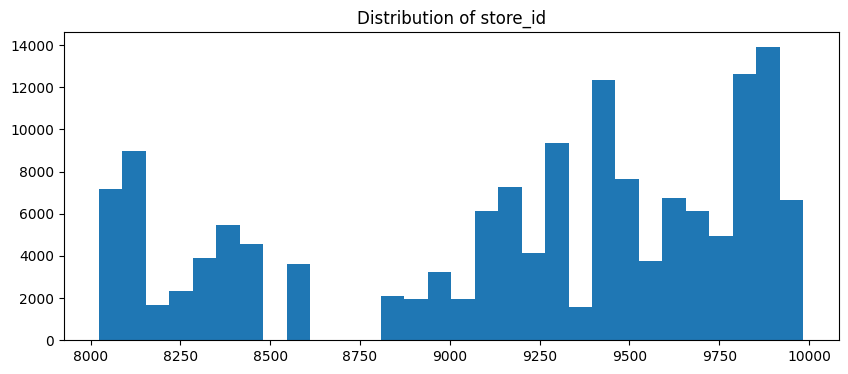

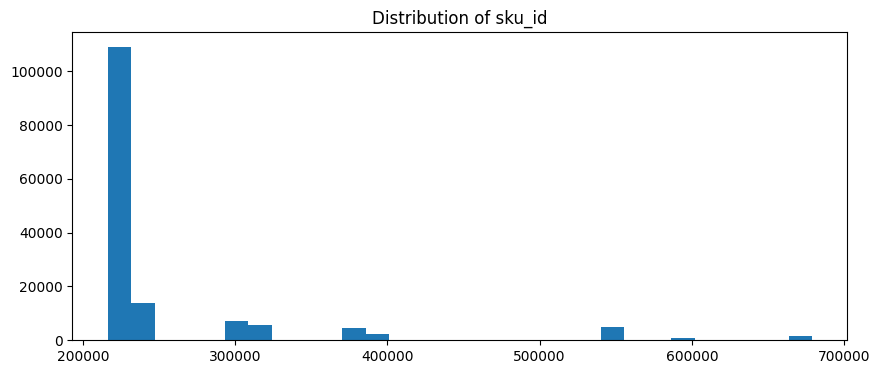

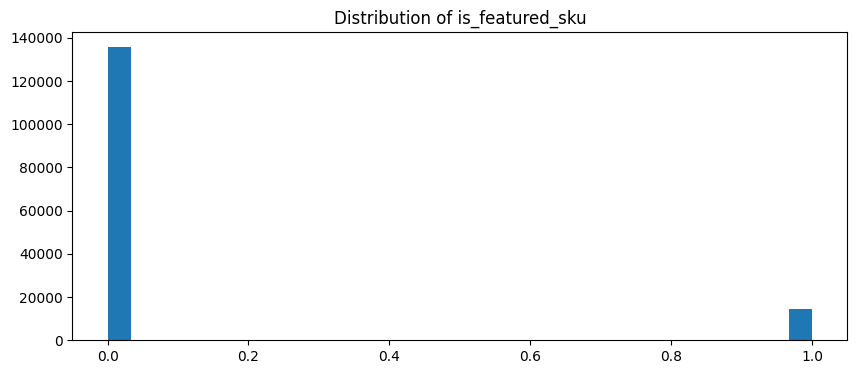

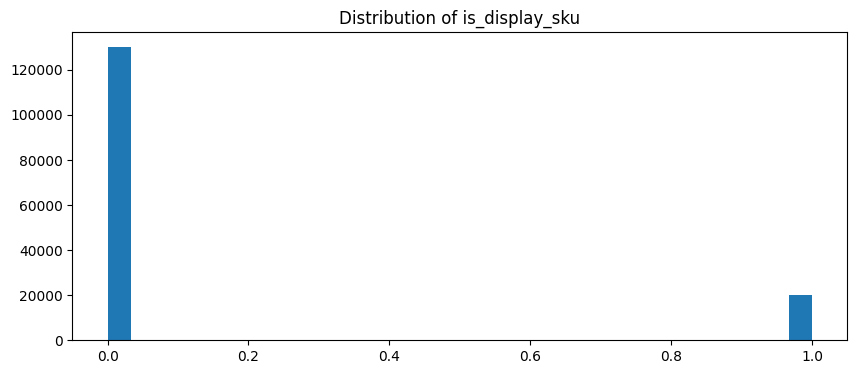

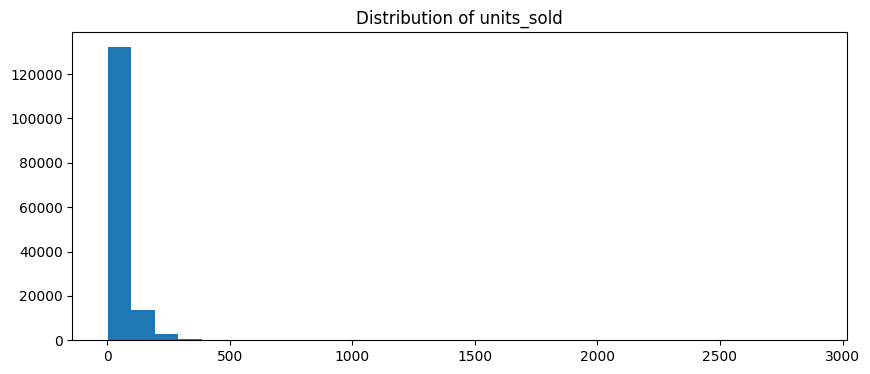

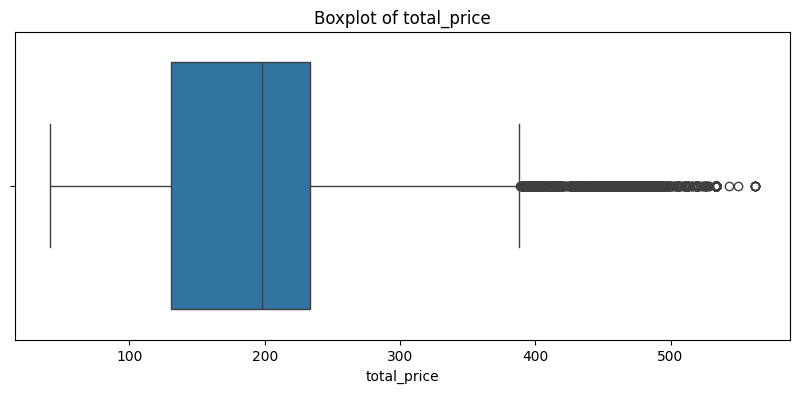

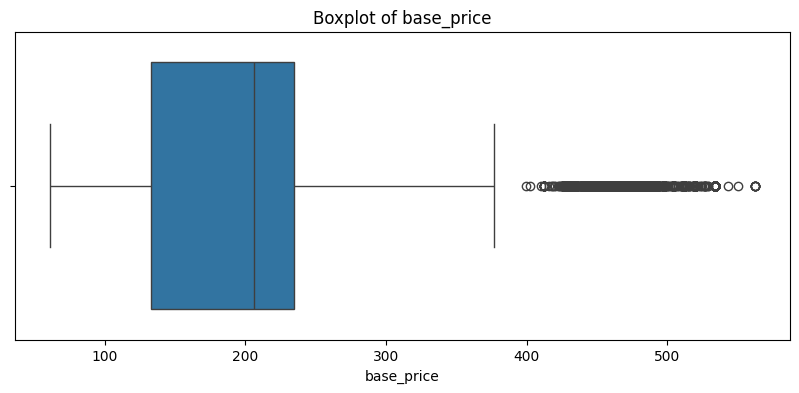

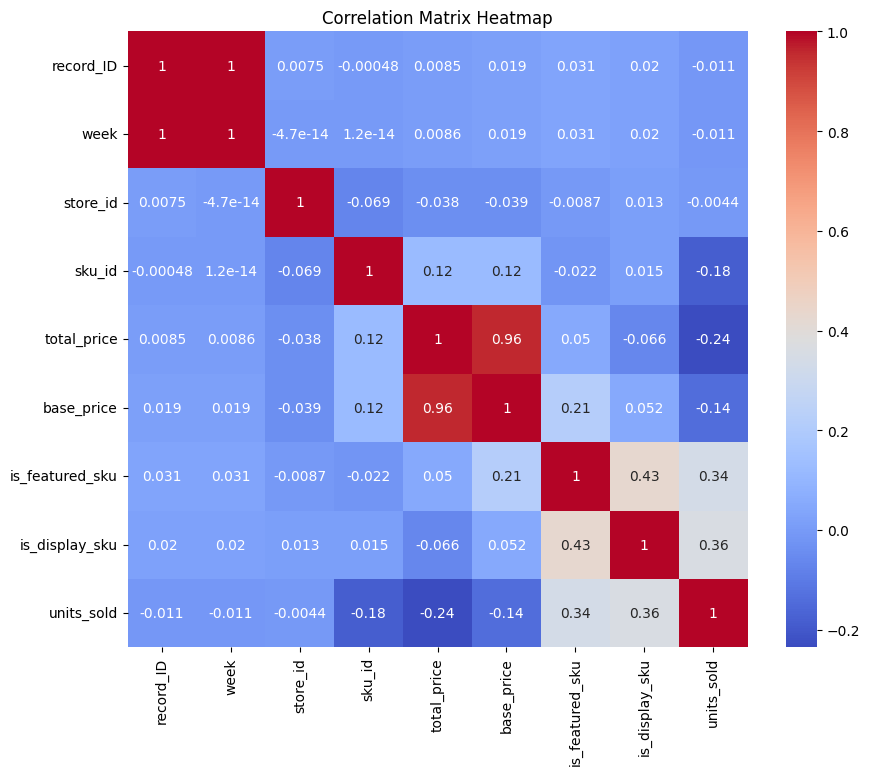

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histograms for categorical columns and the target variable
categorical_cols = ['store_id', 'sku_id', 'is_featured_sku', 'is_display_sku', 'units_sold']

for col in categorical_cols:
    plt.figure(figsize=(10,4))
    plt.hist(dataset[col], bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

# Boxplot for numerical columns
numerical_cols = ['total_price', 'base_price']

for col in numerical_cols:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=dataset[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Check the correlation between features
correlation = dataset.corr()

# Plot a heatmap of the correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()


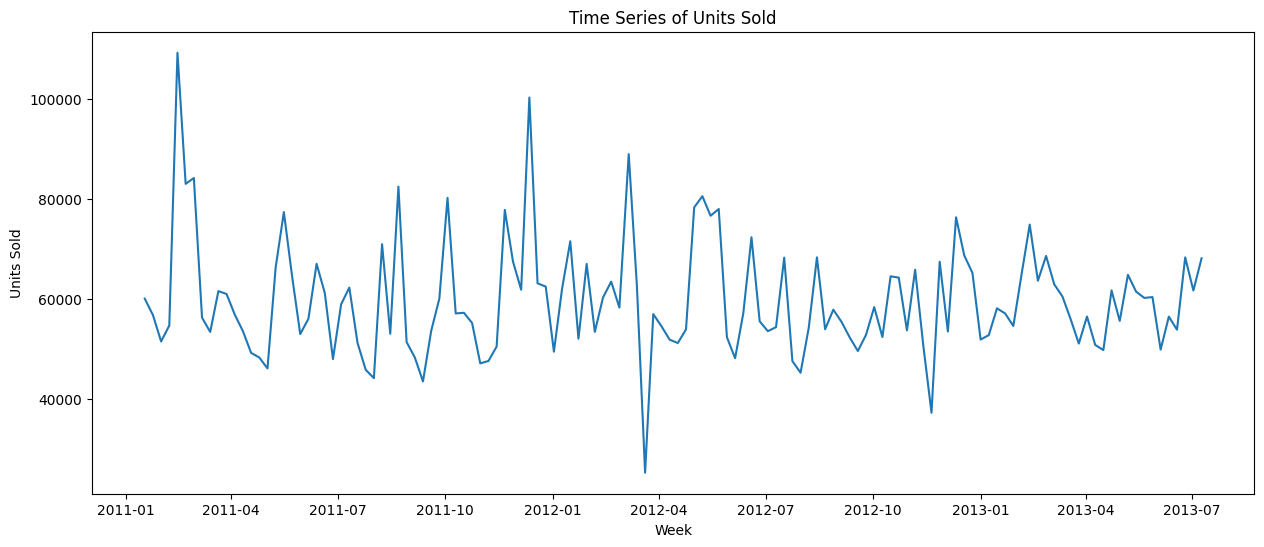

In [9]:
# Plot the time series of 'units_sold'
plt.figure(figsize=(15, 6))
plt.plot(weekly_data['week'], weekly_data['units_sold'])
plt.title('Time Series of Units Sold')
plt.xlabel('Week')
plt.ylabel('Units Sold')
plt.show()

In [10]:
# Calculate the percentage change in 'units_sold' from one week to the next
weekly_data['units_sold_pct_change'] = weekly_data['units_sold'].pct_change()

# Calculate the standard deviation of these percentage changes
volatility = weekly_data['units_sold_pct_change'].std()
volatility


0.2605985501452376

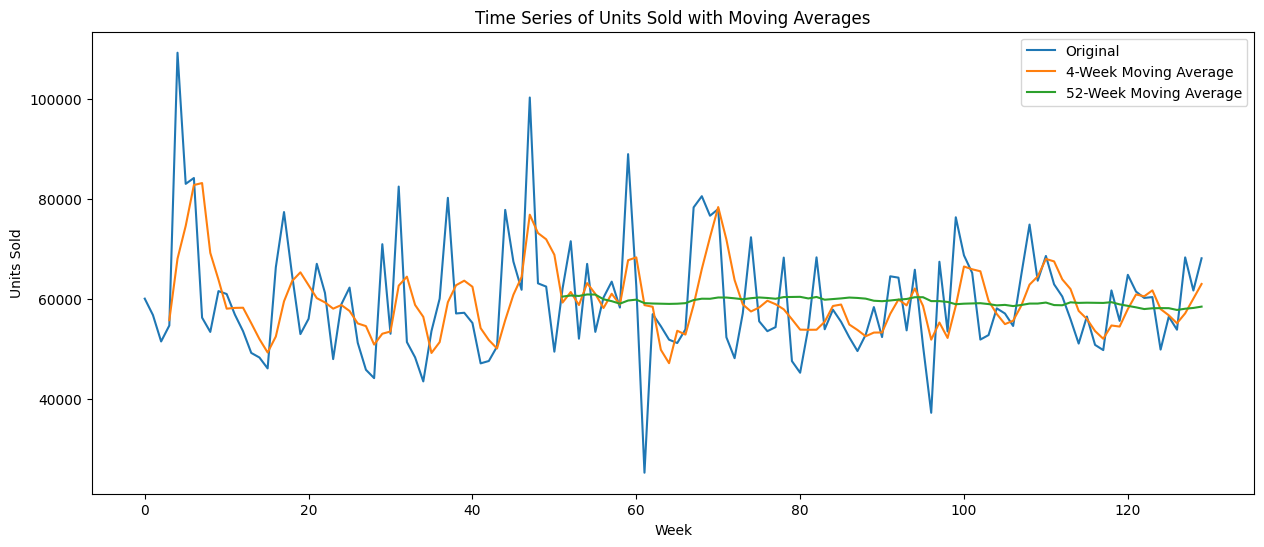

In [11]:
# Calculate the 4-week and 52-week moving averages
weekly_data['4_week_MA'] = weekly_data['units_sold'].rolling(window=4).mean()
weekly_data['52_week_MA'] = weekly_data['units_sold'].rolling(window=52).mean()

# Plot the original time series and the moving averages
plt.figure(figsize=(15, 6))

plt.plot(weekly_data['units_sold'], label='Original')
plt.plot(weekly_data['4_week_MA'], label='4-Week Moving Average')
plt.plot(weekly_data['52_week_MA'], label='52-Week Moving Average')

plt.title('Time Series of Units Sold with Moving Averages')
plt.xlabel('Week')
plt.ylabel('Units Sold')
plt.legend()

plt.show()

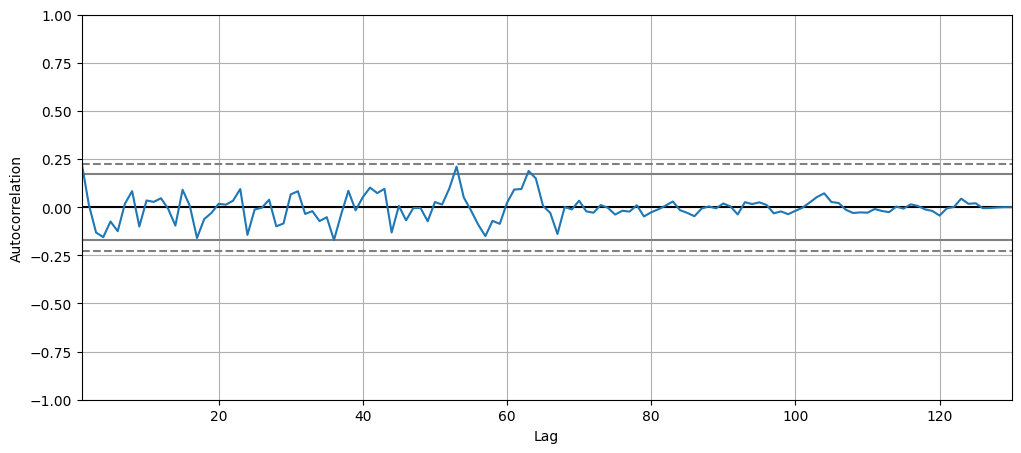

In [12]:
from pandas.plotting import autocorrelation_plot

# Plot the autocorrelation
plt.figure(figsize=(12, 5))
autocorrelation_plot(weekly_data['units_sold'])
plt.show()

In [13]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
from math import sqrt

# Split the data into train and test sets
train_data = weekly_data['units_sold'][:int(0.8*(len(weekly_data)))]
test_data = weekly_data['units_sold'][int(0.8*(len(weekly_data))):]

# Fit the model
model = ExponentialSmoothing(train_data, seasonal='add', seasonal_periods=52).fit()

In [15]:
import pandas as pd

# Resample the data to a weekly frequency
# Ensure 'week' column is the index before resampling
weekly_data_resampled = weekly_data.set_index('week')['units_sold'].resample('W').sum()

# Split the resampled data into train and test sets
train_data_resampled = weekly_data_resampled[:int(0.8*(len(weekly_data_resampled)))]
test_data_resampled = weekly_data_resampled[int(0.8*(len(weekly_data_resampled))):]

# Fit the model to the resampled data
model_resampled = ExponentialSmoothing(train_data_resampled, seasonal='add', seasonal_periods=52).fit()

# Generate predictions on the resampled data
predictions_resampled = model_resampled.predict(start=test_data_resampled.index[0], end=test_data_resampled.index[-1])

# Calculate the root mean squared error (RMSE) on the resampled data
rmse_resampled = sqrt(mean_squared_error(test_data_resampled, predictions_resampled))
rmse_resampled

9099.893108581457

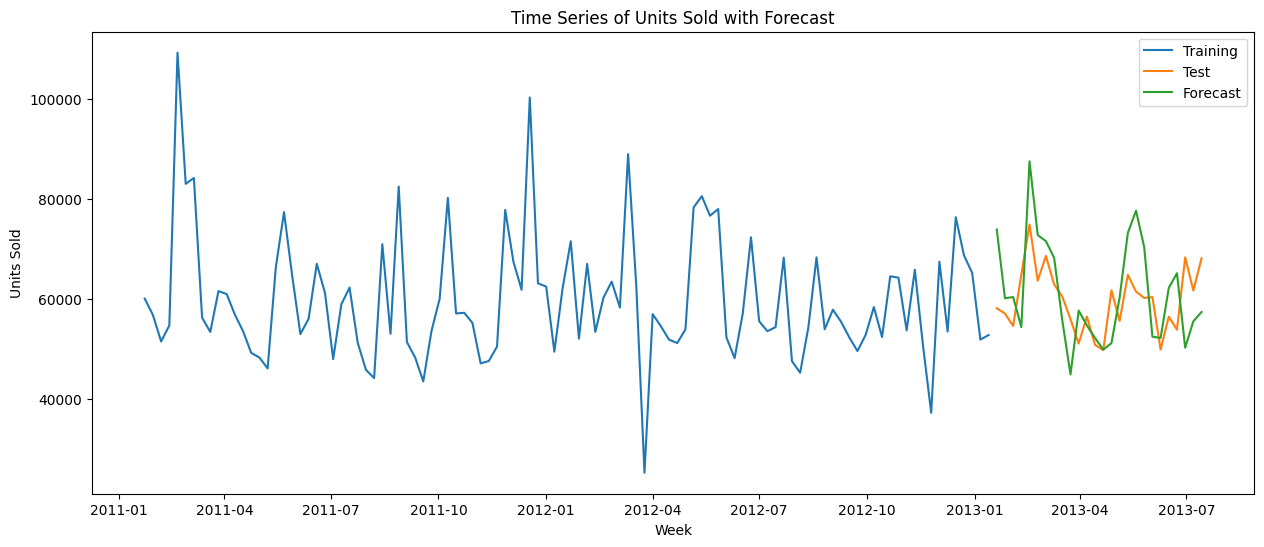

In [16]:
# Plot the original time series and the forecasted values
plt.figure(figsize=(15, 6))

plt.plot(train_data_resampled, label='Training')
plt.plot(test_data_resampled, label='Test')
plt.plot(predictions_resampled, label='Forecast')

plt.title('Time Series of Units Sold with Forecast')
plt.xlabel('Week')
plt.ylabel('Units Sold')
plt.legend()

plt.show()


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Holt-Winters RMSE: 9099.893108581457
ARIMA RMSE: 6235.736166484375
Prophet RMSE: 7710.308484078297


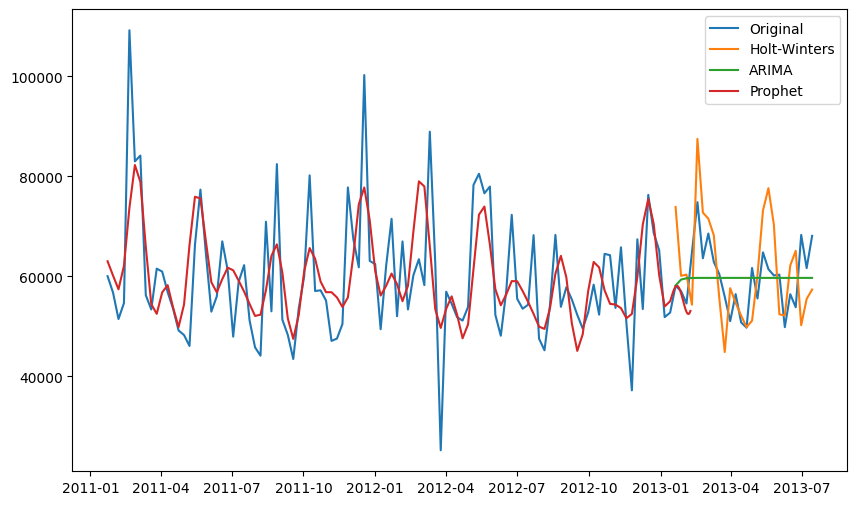

The best model is: ARIMA


In [17]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('demand.csv')

# Convert the 'week' column to datetime format and set it as the index
data['week'] = pd.to_datetime(data['week'], format='%d/%m/%y')
data.set_index('week', inplace=True)

# Aggregate the data by week
weekly_data = data['units_sold'].resample('W').sum()

# Split the data into train and test sets
train_data = weekly_data[:int(0.8*(len(weekly_data)))]
test_data = weekly_data[int(0.8*(len(weekly_data))):]

# Fit a Holt-Winters model
hw_model = ExponentialSmoothing(train_data, seasonal='add', seasonal_periods=52).fit()

# Generate predictions from the Holt-Winters model
hw_predictions = hw_model.predict(start=test_data.index[0], end=test_data.index[-1])

# Fit an ARIMA model
arima_model = ARIMA(train_data, order=(1, 0, 0)).fit()

# Generate predictions from the ARIMA model
arima_predictions = arima_model.predict(start=test_data.index[0], end=test_data.index[-1])

# Prepare the data for Prophet
prophet_data = weekly_data.reset_index()
prophet_data.columns = ['ds', 'y']

# Split the data into train and test sets
train_data_prophet = prophet_data[:int(0.8*(len(prophet_data)))]
test_data_prophet = prophet_data[int(0.8*(len(prophet_data))):]

# Fit a Prophet model
prophet_model = Prophet(yearly_seasonality=True)
prophet_model.fit(train_data_prophet)

# Generate predictions from the Prophet model
prophet_future = prophet_model.make_future_dataframe(periods=len(test_data_prophet))
prophet_predictions = prophet_model.predict(prophet_future)

# Calculate the RMSE for each model
hw_rmse = sqrt(mean_squared_error(test_data, hw_predictions))
arima_rmse = sqrt(mean_squared_error(test_data, arima_predictions))
prophet_rmse = sqrt(mean_squared_error(test_data_prophet['y'], prophet_predictions['yhat'][-len(test_data_prophet):]))

# Print the RMSE for each model
print(f'Holt-Winters RMSE: {hw_rmse}')
print(f'ARIMA RMSE: {arima_rmse}')
print(f'Prophet RMSE: {prophet_rmse}')

# Plot the original data and the predictions from each model
plt.figure(figsize=(10, 6))
plt.plot(weekly_data, label='Original')
plt.plot(hw_predictions, label='Holt-Winters')
plt.plot(arima_predictions, label='ARIMA')
plt.plot(prophet_predictions['ds'], prophet_predictions['yhat'], label='Prophet')
plt.legend()
plt.show()

# Compare the models and print the name of the best model
rmse_values = [hw_rmse, arima_rmse, prophet_rmse]
model_names = ['Holt-Winters', 'ARIMA', 'Prophet']
best_model = model_names[rmse_values.index(min(rmse_values))]

print(f'The best model is: {best_model}')


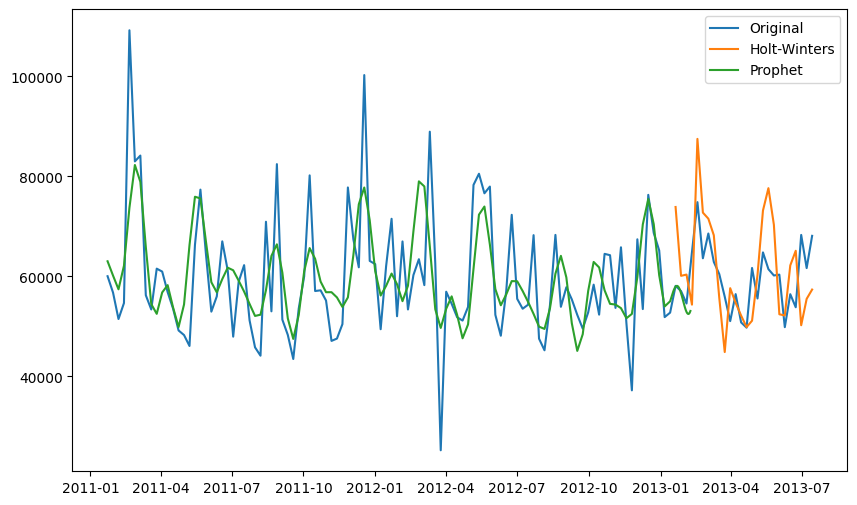

In [18]:
# Plot the original data and the predictions from each model
plt.figure(figsize=(10, 6))
plt.plot(weekly_data, label='Original')
plt.plot(hw_predictions, label='Holt-Winters')
#plt.plot(arima_predictions, label='ARIMA')
plt.plot(prophet_predictions['ds'], prophet_predictions['yhat'], label='Prophet')
plt.legend()
plt.show()

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Holt-Winters RMSE: 9099.893108581457
ARIMA RMSE: 6235.736166484375
Prophet RMSE: 7710.308484078297


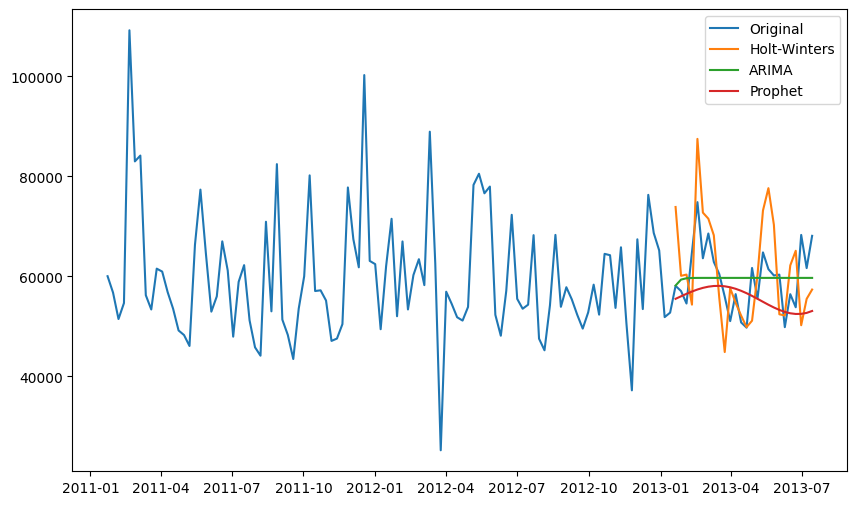

The best model is: ARIMA


In [19]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('demand.csv')

# Convert the 'week' column to datetime format and set it as the index
data['week'] = pd.to_datetime(data['week'], format='%d/%m/%y')
data.set_index('week', inplace=True)

# Aggregate the data by week
weekly_data = data['units_sold'].resample('W').sum()

# Split the data into train and test sets
train_data = weekly_data[:int(0.8*(len(weekly_data)))]
test_data = weekly_data[int(0.8*(len(weekly_data))):]

# Fit a Holt-Winters model
hw_model = ExponentialSmoothing(train_data, seasonal='add', seasonal_periods=52).fit()

# Generate predictions from the Holt-Winters model
hw_predictions = hw_model.predict(start=test_data.index[0], end=test_data.index[-1])

# Fit an ARIMA model
arima_model = ARIMA(train_data, order=(1, 0, 0)).fit()

# Generate predictions from the ARIMA model
arima_predictions = arima_model.predict(start=test_data.index[0], end=test_data.index[-1])

# Prepare the data for Prophet
prophet_data = weekly_data.reset_index()
prophet_data.columns = ['ds', 'y']

# Split the data into train and test sets
train_data_prophet = prophet_data[:int(0.8*(len(prophet_data)))]
test_data_prophet = prophet_data[int(0.8*(len(prophet_data))):]

# Fit a Prophet model
prophet_model = Prophet(yearly_seasonality=True)
prophet_model.fit(train_data_prophet)

# Generate predictions from the Prophet model for the test period
prophet_future = prophet_model.make_future_dataframe(periods=len(test_data))
prophet_predictions = prophet_model.predict(prophet_future)

# Calculate the RMSE for each model
hw_rmse = sqrt(mean_squared_error(test_data, hw_predictions))
arima_rmse = sqrt(mean_squared_error(test_data, arima_predictions))
prophet_rmse = sqrt(mean_squared_error(test_data, prophet_predictions['yhat'][-len(test_data):]))

# Print the RMSE for each model
print(f'Holt-Winters RMSE: {hw_rmse}')
print(f'ARIMA RMSE: {arima_rmse}')
print(f'Prophet RMSE: {prophet_rmse}')

# Plot the original data and the predictions from each model
plt.figure(figsize=(10, 6))
plt.plot(weekly_data, label='Original')
plt.plot(hw_predictions, label='Holt-Winters')
plt.plot(arima_predictions, label='ARIMA')
plt.plot(test_data.index, prophet_predictions['yhat'][-len(test_data):].values, label='Prophet')
plt.legend()
plt.show()

# Compare the models and print the name of the best model
rmse_values = [hw_rmse, arima_rmse, prophet_rmse]
model_names = ['Holt-Winters', 'ARIMA', 'Prophet']
best_model = model_names[rmse_values.index(min(rmse_values))]

print(f'The best model is: {best_model}')

In [20]:
data

,record_ID,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
week,,,,,,,,
2011-01-17,1,8091,216418,99.0375,111.8625,0,0,20
2011-01-17,2,8091,216419,99.0375,99.0375,0,0,28
2011-01-17,3,8091,216425,133.9500,133.9500,0,0,19
2011-01-17,4,8091,216233,133.9500,133.9500,0,0,44
2011-01-17,5,8091,217390,141.0750,141.0750,0,0,52
...,...,...,...,...,...,...,...,...
2013-07-09,212638,9984,223245,235.8375,235.8375,0,0,38
2013-07-09,212639,9984,223153,235.8375,235.8375,0,0,30
2013-07-09,212642,9984,245338,357.6750,483.7875,1,1,31


In [21]:
df = data

# Aggregate the data by week
weekly_data_fb = df['units_sold'].resample('W').sum()

# Prepare the data for Prophet
fbprophet_data = weekly_data_fb.reset_index()
fbprophet_data.columns = ['ds', 'y']

In [22]:
df = data

# Aggregate the data by week
weekly_data_fb = df['units_sold'].resample('W').sum()

# Prepare the data for Prophet
fbprophet_data = weekly_data_fb.reset_index()
fbprophet_data.columns = ['ds', 'y']

In [23]:
# Split the data into train and test sets
train_data_prophet = fbprophet_data[:int(0.8*(len(fbprophet_data)))]
test_data_prophet = fbprophet_data[int(0.8*(len(fbprophet_data))):]

In [24]:
len(train_data_prophet)

104

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Fit a Prophet model
prophet_model = Prophet(yearly_seasonality=True)
prophet_model.fit(train_data_prophet)

# Generate predictions from the Prophet model for the test period
prophet_future = prophet_model.make_future_dataframe(periods=len(test_data_prophet))
prophet_predictions = prophet_model.predict(prophet_future)

# Extract the predicted and actual values
prophet_predicted = prophet_predictions[-len(test_data_prophet):]['yhat']
prophet_actual = test_data_prophet['y']

# Calculate the RMSE
prophet_rmse = np.sqrt(mean_squared_error(prophet_actual, prophet_predicted))
print('Prophet RMSE:', prophet_rmse)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet RMSE: 7710.308484078297


In [27]:
final_df = pd.DataFrame(prophet_predictions)
import plotly.graph_objs as go
import plotly.offline as py
#Plot predicted and actual line graph with X=dates, Y=Outbound
actual_chart = go.Scatter(y=train_data_prophet["y"], name= 'Actual')
predict_chart = go.Scatter(y=final_df["yhat"], name= 'Predicted')
predict_chart_upper = go.Scatter(y=final_df["yhat_upper"], name= 'Predicted Upper')
predict_chart_lower = go.Scatter(y=final_df["yhat_lower"], name= 'Predicted Lower')
py.plot([actual_chart, predict_chart, predict_chart_upper, predict_chart_lower])

'temp-plot.html'